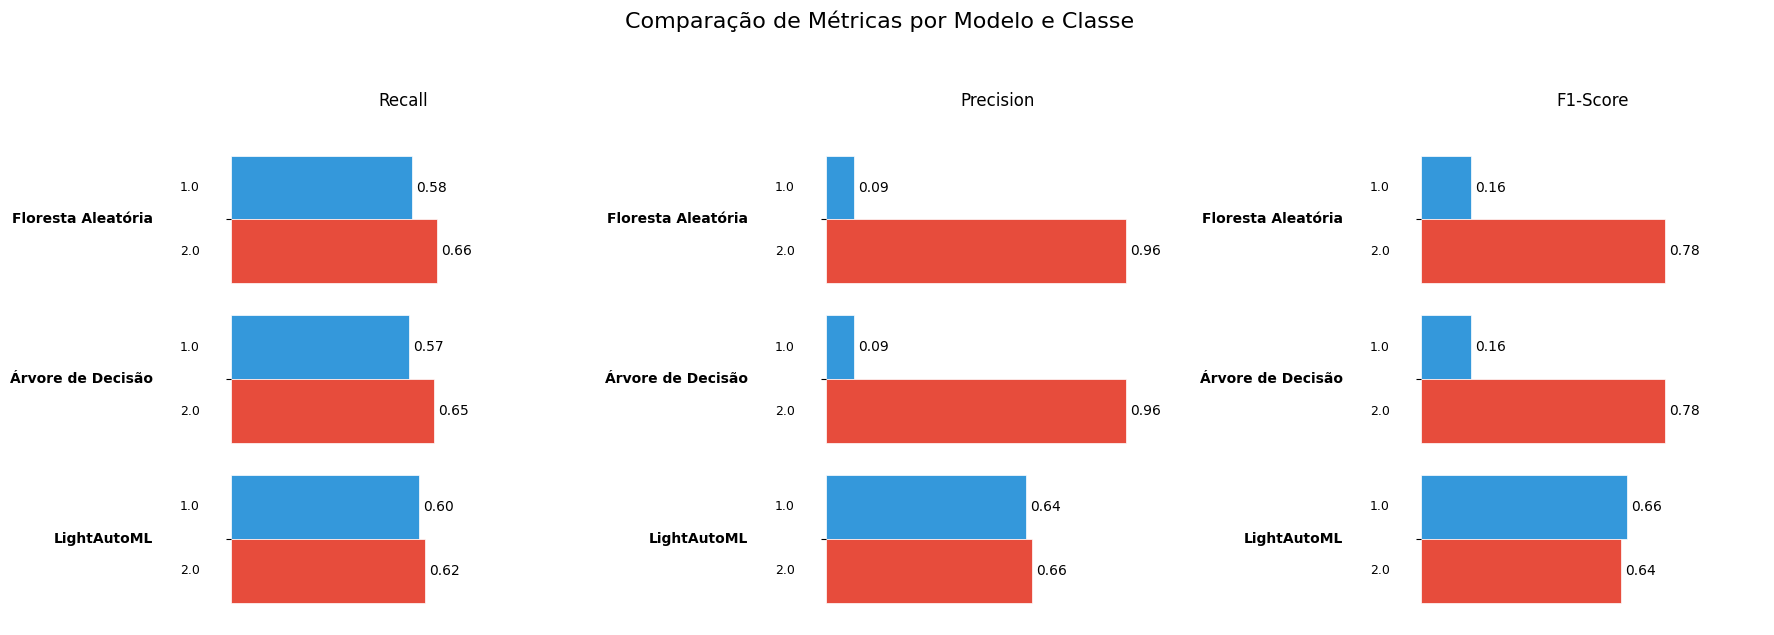

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Dados
métricas = ['Recall', 'Precision', 'F1-Score']
modelos = ['LightAutoML', 
           'Árvore de Decisão', 
           'Floresta Aleatória']


dados = {
    'Precision': {
        'LightAutoML': [0.64, 0.66],
        'Árvore de Decisão': [0.09, 0.96],
        'Floresta Aleatória': [0.09, 0.96],
    },
    'Recall': {
        'LightAutoML': [0.60, 0.62],
        'Árvore de Decisão': [0.57, 0.65],
        'Floresta Aleatória': [0.58, 0.66],
    },
    'F1-Score': {
        'LightAutoML': [0.66, 0.64],
        'Árvore de Decisão': [0.16, 0.78],
        'Floresta Aleatória': [0.16, 0.78],
    }
}

# Configuração dos gráficos
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparação de Métricas por Modelo e Classe', fontsize=16, y=1.05)

# Cores personalizadas
cores = ['#3498db', '#e74c3c']  # Azul e vermelho

for i, métrica in enumerate(métricas):
    ax = axs[i]
    y = np.arange(len(modelos))
    largura = 0.4
    
    # Barras para classe 1.0 (em cima)
    bars1 = ax.barh(y + largura/2, 
                   [dados[métrica][modelo][0] for modelo in modelos],
                   largura, color=cores[0], edgecolor='white', linewidth=0.5)
    
    # Barras para classe 2.0 (embaixo)
    bars2 = ax.barh(y - largura/2, 
                   [dados[métrica][modelo][1] for modelo in modelos],
                   largura, color=cores[1], edgecolor='white', linewidth=0.5)
    
    # Valores nas barras
    ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=10)
    ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=10)
    
    # Configurações do eixo Y
    ax.set_yticks(y)
    ax.set_yticklabels([])  # Remove os nomes padrão
    
    # Adiciona os rótulos personalizados
    for j, modelo in enumerate(modelos):
        ax.text(-0.1, j + largura/2, '1.0', ha='right', va='center', fontsize=9)
        ax.text(-0.1, j - largura/2, '2.0', ha='right', va='center', fontsize=9)
        ax.text(-0.25, j, modelo, ha='right', va='center', fontsize=10, fontweight='bold')
    
    ax.set_title(métrica, pad=20, fontsize=12)
    ax.set_xlim(0, 1.1)
    
    # Remover todos os eixos (spines)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    
    # Remover ticks do eixo x
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()